In [1]:
!pip install hdbscan

In [2]:
!pip install hdbscan -q

In [3]:
!pip install -U hdbscan scikit-learn scipy numpy pandas matplotlib networkx -q

In [4]:
import sys

!{sys.executable} -m pip uninstall -y numpy scipy scikit-learn hdbscan joblib threadpoolctl
!{sys.executable} -m pip install --upgrade pip setuptools wheel
!{sys.executable} -m pip install --no-cache-dir --upgrade numpy scipy scikit-learn pandas matplotlib networkx cython hdbscan

Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Found existing installation: hdbscan 0.8.42
Uninstalling hdbscan-0.8.42:
  Successfully uninstalled hdbscan-0.8.42
Found existing installation: joblib 1.5.3
Uninstalling joblib-1.5.3:
  Successfully uninstalled joblib-1.5.3
Found existing installation: threadpoolctl 3.6.0
Uninstalling threadpoolctl-3.6.0:
  Successfully uninstalled threadpoolctl-3.6.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 171.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 286.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 265.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 279.0 MB/s  0:00:00


In [5]:
import importlib.metadata as md

packages = [
    "numpy",
    "scipy",
    "scikit-learn",
    "hdbscan",
    "pandas",
    "matplotlib",
    "networkx",
    "cython"
]

for pkg in packages:
    print(pkg, md.version(pkg))

numpy 2.4.4
scipy 1.17.1
scikit-learn 1.8.0
hdbscan 0.8.42
pandas 3.0.2
matplotlib 3.10.9
networkx 3.6.1
cython 3.2.4


Clusters encontrados: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Contagem por cluster: (array([-1,  0,  1,  2]), array([ 46, 263, 256, 265]))


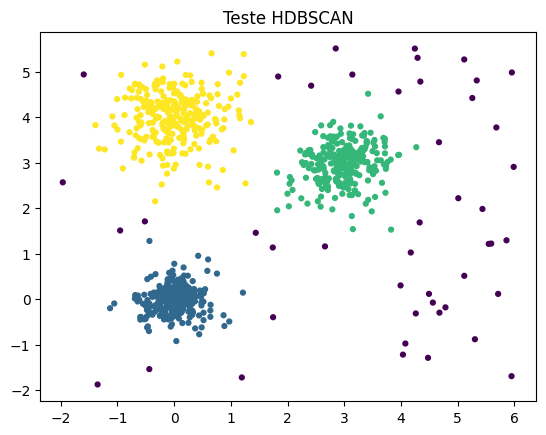

In [6]:
import numpy as np
import hdbscan
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

cluster_1 = rng.normal(loc=[0, 0], scale=0.30, size=(250, 2))
cluster_2 = rng.normal(loc=[3, 3], scale=0.40, size=(250, 2))
cluster_3 = rng.normal(loc=[0, 4], scale=0.50, size=(250, 2))
noise = rng.uniform(low=-2, high=6, size=(80, 2))

X = np.vstack([cluster_1, cluster_2, cluster_3, noise])



clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5
)



labels = clusterer.fit_predict(X)

print("Clusters encontrados:", sorted(set(labels)))
print("Contagem por cluster:", np.unique(labels, return_counts=True))

plt.scatter(X[:, 0], X[:, 1], c=labels, s=12)
plt.title("Teste HDBSCAN")
plt.show()

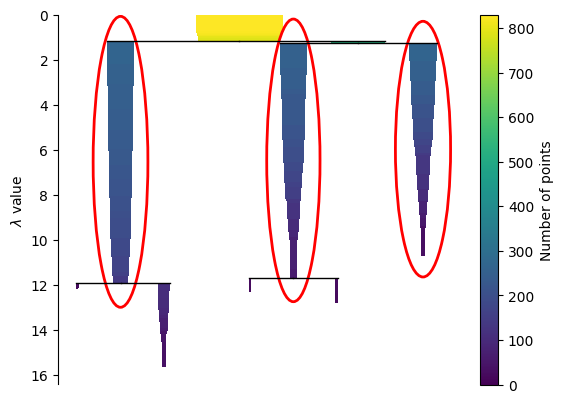

In [7]:
clusterer.condensed_tree_.plot(select_clusters=True)
plt.show()

In [8]:
import pandas as pd

df_resultado = pd.DataFrame(X, columns=["x", "y"])
df_resultado["cluster"] = labels
df_resultado.head()

,x,y,cluster
0,0.091415,-0.311995,0
1,0.225135,0.282169,0
2,-0.585311,-0.390654,0
3,0.038352,-0.094873,0
4,-0.005040,-0.255913,0


In [9]:
df_tree = clusterer.condensed_tree_.to_pandas()
df_tree.head()

,parent,child,lambda_val,child_size
0,830,789,0.523774,1
1,830,769,0.614640,1
2,830,760,0.617912,1
3,830,763,0.620349,1
4,830,772,0.716171,1


In [10]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

X2, y_true = make_blobs(
    n_samples=1000,
    centers=4,
    random_state=42
)

X2 = StandardScaler().fit_transform(X2)

clusterer2 = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5
)

labels2 = clusterer2.fit_predict(X2)

print("Clusters:", sorted(set(labels2)))
print("Contagem:", np.unique(labels2, return_counts=True))

Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Contagem: (array([0, 1, 2, 3]), array([250, 250, 251, 249]))
